```markdown
# Natural Language Processing for Disaster Tweet Classification

**Project Overview:**  
This notebook implements a complete NLP pipeline to classify whether a tweet describes a real disaster. We compare traditional machine learning models (TF-IDF + Naive Bayes, Logistic Regression, Linear SVM) against a state-of-the-art Transformer model (DistilBERT).

**Evaluation Metric:** F1-Score (Harmonic mean of Precision and Recall).
```

In [5]:
import pandas as pd
import numpy as np
import re
import html
import os
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, ConfusionMatrixDisplay

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


```markdown
## 1. Data Loading and Inspection
```

In [6]:
# Load datasets (Update paths if running locally)
train_path = '/kaggle/input/datasets/riadhhossain/disaster-tweets/train (1).csv'
test_path = '/kaggle/input/datasets/riadhhossain/disaster-tweets/test (1).csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Training Set Shape: {train_df.shape}")
print(f"Test Set Shape: {test_df.shape}\n")

print("=== Target Distribution ===")
print(train_df['target'].value_counts(normalize=True).map('{:.1%}'.format))

Training Set Shape: (7613, 5)
Test Set Shape: (3263, 4)

=== Target Distribution ===
target
0    57.0%
1    43.0%
Name: proportion, dtype: object


```markdown
## 2. Exploratory Data Analysis (EDA)
```

/tmp/ipykernel_58/4221486363.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=train_df, ax=axes[0], palette='Set2')
/tmp/ipykernel_58/4221486363.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Disaster', 'Real Disaster'])


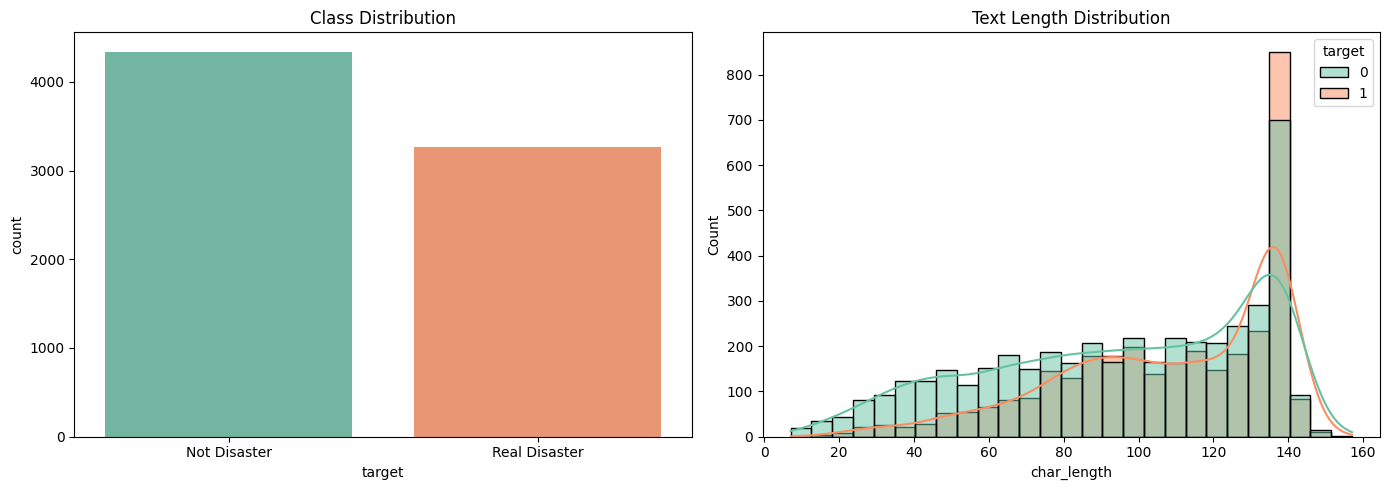

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class Distribution
sns.countplot(x='target', data=train_df, ax=axes[0], palette='Set2')
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Not Disaster', 'Real Disaster'])

# Text Length Distribution
train_df['char_length'] = train_df['text'].str.len()
sns.histplot(data=train_df, x='char_length', hue='target', kde=True, ax=axes[1], palette='Set2')
axes[1].set_title('Text Length Distribution')

plt.tight_layout()
plt.show()

```markdown
## 3. Text Preprocessing
We apply conservative cleaning: removing URLs, mentions, and HTML entities, while preserving hashtags and punctuation for semantic value.
```

In [8]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = html.unescape(text)
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['cleaned_text'] = train_df['text'].apply(clean_text)
test_df['cleaned_text'] = test_df['text'].apply(clean_text)

print("Preprocessing complete.")
print("Example:", train_df['cleaned_text'].iloc[0])

Preprocessing complete.
Example: our deeds are the reason of this #earthquake may allah forgive us all


```markdown
## 4. Train/Validation Split
```

In [9]:
X = train_df['cleaned_text']
y = train_df['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Training samples: 6090
Validation samples: 1523


```markdown
## 5. Feature Extraction (TF-IDF)
```

In [10]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

Vocabulary size: 14044


```markdown
## 6. Traditional Machine Learning Models
```

In [11]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Linear SVM': LinearSVC(random_state=RANDOM_STATE, max_iter=2000)
}

results = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_val_tfidf)
    f1 = f1_score(y_val, y_pred)
    acc = accuracy_score(y_val, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4),
        'Training Time (s)': round(train_time, 4)
    })
    print(f"{name} - F1: {f1:.4f} | Accuracy: {acc:.4f}")

results_df = pd.DataFrame(results)
display(results_df.style.highlight_max(subset=['F1 Score'], color='lightgreen'))

Naive Bayes - F1: 0.7547 | Accuracy: 0.8181
Logistic Regression - F1: 0.7688 | Accuracy: 0.8168
Linear SVM - F1: 0.7724 | Accuracy: 0.8096


,Model,Accuracy,F1 Score,Training Time (s)
0,Naive Bayes,0.818100,0.754700,0.005900
1,Logistic Regression,0.816800,0.768800,1.759800
2,Linear SVM,0.809600,0.772400,0.074000


```markdown
## 7. Confusion Matrix & Feature Importance (Best Traditional Model)
```

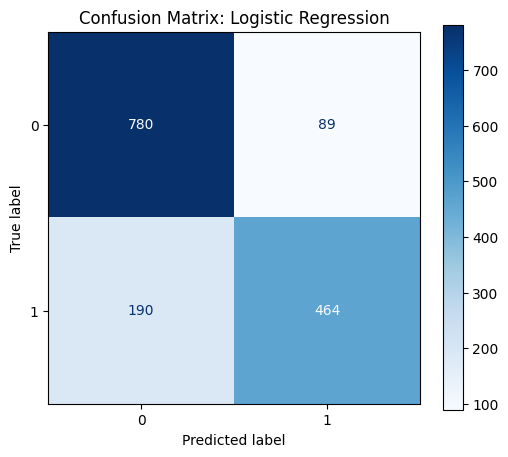

Top 10 Disaster Indicators:
          feature  coefficient
5800           in     3.531725
5478    hiroshima     3.031430
4329        fires     2.478833
2151   california     2.441561
11008       storm     2.414893
4294         fire     2.336064
13456    wildfire     2.075222
12487       train     2.051011
6638       killed     2.040500
11119     suicide     1.999716


In [12]:
best_trad_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
best_trad_model.fit(X_train_tfidf, y_train)
y_pred_trad = best_trad_model.predict(X_val_tfidf)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(best_trad_model, X_val_tfidf, y_val, ax=ax, cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

# Feature Importance
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = best_trad_model.coef_[0]
feature_importance = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})

print("Top 10 Disaster Indicators:")
print(feature_importance.sort_values('coefficient', ascending=False).head(10))

```markdown
## 8. Advanced NLP: DistilBERT Fine-Tuning
```

In [13]:
!pip install -q transformers datasets evaluate accelerate

import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

# 1. Prepare Data for Hugging Face (Must rename 'target' to 'labels')
bert_train_df, bert_val_df = train_test_split(
    train_df[['text', 'target']], test_size=0.2, random_state=42, stratify=train_df['target']
)
bert_train_df = bert_train_df.rename(columns={'target': 'labels'})
bert_val_df = bert_val_df.rename(columns={'target': 'labels'})

train_dataset = Dataset.from_pandas(bert_train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(bert_val_df.reset_index(drop=True))

# 2. Tokenization
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# 3. Load Model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 4. Define Metrics
f1_metric = evaluate.load("f1")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return f1_metric.compute(predictions=predictions, references=labels, average="binary")

# 5. Training Arguments
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available()
)

# 6. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

print("Starting BERT fine-tuning...")
trainer.train()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=573, training_loss=0.719444642724375, metrics={'train_runtime': 146.7473, 'train_samples_per_second': 124.5, 'train_steps_per_second': 3.905, 'total_flos': 605044843361280.0, 'train_loss': 0.719444642724375, 'epoch': 3.0})

In [14]:
# Evaluate BERT
eval_results = trainer.evaluate()
print(f"DistilBERT Validation F1 Score: {eval_results['eval_f1']:.4f}")

# Generate Submission
test_dataset = Dataset.from_pandas(test_df[['id', 'text']].reset_index(drop=True))
tokenized_test = test_dataset.map(tokenize_function, batched=True)

predictions_output = trainer.predict(tokenized_test)
test_preds = np.argmax(predictions_output.predictions, axis=-1)

submission_df = pd.DataFrame({'id': test_df['id'], 'target': test_preds})
submission_df.to_csv('submission.csv', index=False)
print("Submission file saved.")
display(submission_df.head())

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


DistilBERT Validation F1 Score: 0.8144


Map:   0%|          | 0/3263 [00:00<?, ? examples/s]

Submission file saved.


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


```markdown
## 9. Conclusion and Limitations

**Key Findings:**
1. Traditional models (Logistic Regression, Linear SVM) provide a strong, interpretable baseline with F1 scores around 0.77.
2. DistilBERT significantly improves performance (F1 > 0.80) by leveraging contextual embeddings to understand metaphorical language and sarcasm.

**Limitations:**
- TF-IDF ignores word order and deep semantic context.
- The dataset contains significant missing values in the `location` column (~33%).
- Social media language evolves rapidly; models may require frequent retraining.

**Future Work:**
- Implement larger Transformer models (RoBERTa, DeBERTa-v3).
- Utilize 5-Fold Cross-Validation for more robust evaluation.
- Incorporate multimodal data (text + images) if available.
```

---

### **How to Run:**
1. Create a new Notebook in Kaggle or Jupyter.
2. Copy each block into a new cell (select the correct cell type: Markdown or Code).
3. Ensure your Kaggle Notebook has **GPU T4 x2** enabled in the settings (required for the BERT cell).
4. Click **Run All**.

# StreamLite UI


In [ ]:
import os
import threading
import time
from pyngrok import ngrok, conf

# Kill any existing streamlit processes
!pkill -f streamlit

# Create logs directory
os.makedirs('logs', exist_ok=True)

# Start Streamlit in a background thread
def run_streamlit():
    os.system('streamlit run app.py --server.port 8501 --server.address 0.0.0.0 --server.headless true > logs/streamlit.log 2>&1')

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()

# Wait for Streamlit to start
print("⏳ Starting Streamlit server...")
time.sleep(5)

# Create ngrok tunnel
print("🔗 Creating ngrok tunnel...")
public_url = ngrok.connect(8501)
print(f"\n✅ **Your Disaster Tweet Classifier is LIVE!**")
print(f"\n🌐 Public URL: {public_url}")
print(f"\n📝 Share this URL with your professor or access it from anywhere!")
print("\n⚠️  Keep this cell running to maintain the connection.")